In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score

In [3]:
# Customer data
customer_churn_data = [
    {"customer_id": 1, "tenure_months": 3, "monthly_charges": 75.50, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 2, "tenure_months": 45, "monthly_charges": 20.00, "has_contract": 1, "tech_support": 1, "churn": 0},
    {"customer_id": 3, "tenure_months": 12, "monthly_charges": 85.00, "has_contract": 0, "tech_support": 1, "churn": 0},
    {"customer_id": 4, "tenure_months": 2, "monthly_charges": 95.30, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 5, "tenure_months": 60, "monthly_charges": 115.00, "has_contract": 1, "tech_support": 1, "churn": 0},
    {"customer_id": 6, "tenure_months": 6, "monthly_charges": 45.00, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 7, "tenure_months": 24, "monthly_charges": 65.25, "has_contract": 1, "tech_support": 0, "churn": 0},
    {"customer_id": 8, "tenure_months": 1, "monthly_charges": 80.00, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 9, "tenure_months": 36, "monthly_charges": 50.75, "has_contract": 1, "tech_support": 1, "churn": 0},
    {"customer_id": 10, "tenure_months": 8, "monthly_charges": 100.10, "has_contract": 0, "tech_support": 1, "churn": 1},
    {"customer_id": 11, "tenure_months": 52, "monthly_charges": 25.00, "has_contract": 1, "tech_support": 0, "churn": 0},
    {"customer_id": 12, "tenure_months": 4, "monthly_charges": 105.00, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 13, "tenure_months": 18, "monthly_charges": 70.00, "has_contract": 0, "tech_support": 1, "churn": 0},
    {"customer_id": 14, "tenure_months": 71, "monthly_charges": 118.40, "has_contract": 1, "tech_support": 1, "churn": 0},
    {"customer_id": 15, "tenure_months": 5, "monthly_charges": 89.90, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 16, "tenure_months": 65, "monthly_charges": 19.95, "has_contract": 1, "tech_support": 0, "churn": 0},
    {"customer_id": 17, "tenure_months": 2, "monthly_charges": 70.15, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 18, "tenure_months": 15, "monthly_charges": 49.90, "has_contract": 1, "tech_support": 1, "churn": 0},
    {"customer_id": 19, "tenure_months": 9, "monthly_charges": 86.40, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 20, "tenure_months": 48, "monthly_charges": 99.50, "has_contract": 1, "tech_support": 1, "churn": 0},
    {"customer_id": 21, "tenure_months": 14, "monthly_charges": 78.80, "has_contract": 0, "tech_support": 1, "churn": 0},
    {"customer_id": 22, "tenure_months": 3, "monthly_charges": 60.00, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 23, "tenure_months": 31, "monthly_charges": 81.20, "has_contract": 1, "tech_support": 0, "churn": 0},
    {"customer_id": 24, "tenure_months": 1, "monthly_charges": 90.05, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 25, "tenure_months": 55, "monthly_charges": 24.50, "has_contract": 1, "tech_support": 1, "churn": 0},
    {"customer_id": 26, "tenure_months": 11, "monthly_charges": 93.85, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 27, "tenure_months": 42, "monthly_charges": 60.10, "has_contract": 1, "tech_support": 1, "churn": 0},
    {"customer_id": 28, "tenure_months": 7, "monthly_charges": 85.90, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 29, "tenure_months": 22, "monthly_charges": 40.30, "has_contract": 1, "tech_support": 0, "churn": 0},
    {"customer_id": 30, "tenure_months": 5, "monthly_charges": 101.20, "has_contract": 0, "tech_support": 1, "churn": 1},
    {"customer_id": 31, "tenure_months": 68, "monthly_charges": 110.00, "has_contract": 1, "tech_support": 1, "churn": 0},
    {"customer_id": 32, "tenure_months": 4, "monthly_charges": 72.00, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 33, "tenure_months": 26, "monthly_charges": 88.50, "has_contract": 1, "tech_support": 1, "churn": 0},
    {"customer_id": 34, "tenure_months": 10, "monthly_charges": 95.00, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 35, "tenure_months": 50, "monthly_charges": 30.00, "has_contract": 1, "tech_support": 0, "churn": 0},
    {"customer_id": 36, "tenure_months": 1, "monthly_charges": 69.95, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 37, "tenure_months": 38, "monthly_charges": 74.20, "has_contract": 1, "tech_support": 1, "churn": 0},
    {"customer_id": 38, "tenure_months": 6, "monthly_charges": 84.10, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 39, "tenure_months": 58, "monthly_charges": 104.05, "has_contract": 1, "tech_support": 1, "churn": 0},
    {"customer_id": 40, "tenure_months": 13, "monthly_charges": 55.00, "has_contract": 0, "tech_support": 1, "churn": 0},
    {"customer_id": 41, "tenure_months": 2, "monthly_charges": 91.25, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 42, "tenure_months": 33, "monthly_charges": 63.80, "has_contract": 1, "tech_support": 0, "churn": 0},
    {"customer_id": 43, "tenure_months": 16, "monthly_charges": 102.50, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 44, "tenure_months": 61, "monthly_charges": 20.25, "has_contract": 1, "tech_support": 1, "churn": 0},
    {"customer_id": 45, "tenure_months": 8, "monthly_charges": 79.00, "has_contract": 0, "tech_support": 1, "churn": 1},
    {"customer_id": 46, "tenure_months": 29, "monthly_charges": 92.00, "has_contract": 1, "tech_support": 1, "churn": 0},
    {"customer_id": 47, "tenure_months": 4, "monthly_charges": 83.30, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 48, "tenure_months": 40, "monthly_charges": 45.00, "has_contract": 1, "tech_support": 0, "churn": 0},
    {"customer_id": 49, "tenure_months": 12, "monthly_charges": 106.15, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 50, "tenure_months": 72, "monthly_charges": 115.50, "has_contract": 1, "tech_support": 1, "churn": 0},
    {"customer_id": 51, "tenure_months": 3, "monthly_charges": 71.10, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 52, "tenure_months": 20, "monthly_charges": 64.00, "has_contract": 1, "tech_support": 1, "churn": 0},
    {"customer_id": 53, "tenure_months": 9, "monthly_charges": 97.80, "has_contract": 0, "tech_support": 0, "churn": 1},
    {"customer_id": 54, "tenure_months": 44, "monthly_charges": 82.50, "has_contract": 1, "tech_support": 0, "churn": 0},
    {"customer_id": 55, "tenure_months": 1, "monthly_charges": 50.00, "has_contract": 0, "tech_support": 0, "churn": 1}
]

In [4]:
# Create a DataFrame from the customer churn data
df = pd.DataFrame(customer_churn_data)
print(df.head())

   customer_id  tenure_months  monthly_charges  has_contract  tech_support  \
0            1              3             75.5             0             0   
1            2             45             20.0             1             1   
2            3             12             85.0             0             1   
3            4              2             95.3             0             0   
4            5             60            115.0             1             1   

   churn  
0      1  
1      0  
2      0  
3      1  
4      0  


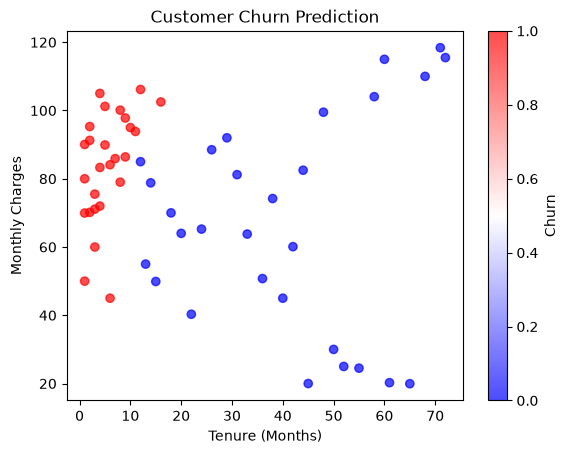

In [5]:
import matplotlib.pyplot as plt
plt.scatter(df['tenure_months'], df['monthly_charges'], c=df['churn'], cmap='bwr', alpha=0.7)
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges')
plt.title('Customer Churn Prediction')
plt.colorbar(label='Churn')
plt.show()

In [6]:
# Split the data into features and target variable
X = df[["tenure_months", "monthly_charges", "has_contract", "tech_support"]]
y = df["churn"]

In [7]:
# Select model and train it
model = LogisticRegression()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [8]:
# Metrics and evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


Accuracy: 0.91
Precision: 1.00
Recall: 0.67
F1 Score: 0.80
